<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
    Temas Selectos: Python para Ciencias de la Tierra
  </span>
  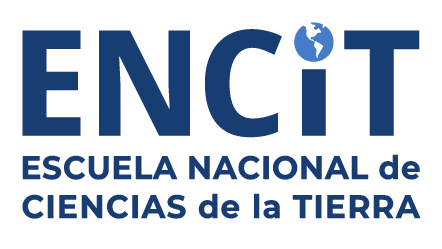 
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema 3: Estadistica aplicada </span><br/>
  <span style="color:DodgerBlue; font-size:140%;">Notebook: Regresión no lineal </span><br/>
  <span style="font-size:100%;color:forestgreen"> Escuela Nacional de Ciencias de la Tierra  |  Semestre 2026-II</span>
</p>

---

### **<font color="ForestGreen"> Recapitulando sobre la regresión: </font>**


1. Método de ajuste de una función para describir la relación entre dos (simple) o más (multivariada) variables.
2. La función que queramos ajustar a los datos puede ser la ecuación de la recta (regresión lineal) o no, como veremos en este notebook. 
3. El grado de bondad del ajuste (¿qué tan buena es mi función resultante para describir mi relación entre mis datos) se mide con a) medidas del error y b) coeficientes de correlación o determinación.
4. El proceso de ajustar los datos a la función objetivo busca minimizar el error cuadrático entre una predicción $\hat{y}$ y los datos. Por eso se conoce como método de **mínimos cuadrados**. 
5. Un objetivo de hacer una regresión es **evaluar** el tipo y fortaleza en la relación entre dos variables. ¿Hay relación lineal? ¿Es fuerte? Otro objetivo es predecir o clasificar datos. Por ejemplo, yo tengo datos medidos de dos variables en 1 sitio y tienen fuerte relación. Puedo usar esta relación para **predecir** cómo será la variable dependiente en un sitio donde no pueda medirla.  


### **<font color="ForestGreen"> Otros tipos de regresión </font>**

A diferencia de la regresión lineal, donde el modelo asume una relación lineal entre las variables, en la regresión no lineal, el modelo puede tener una forma funcional más compleja, como exponencial, logarítmica, polinómica, sigmoidal, entre otras.

Por ejemplo, en la regresión exponencial, el modelo asume una relación de la forma $y=a e^{bx}$, donde $y$ es la variable dependiente, $x$ es la variable independiente, $a$ y $b$ son parámetros del modelo, y $e$ es la base del logaritmo natural. Este tipo de relación se encuentra comúnmente en fenómenos que exhiben un crecimiento o decaimiento exponencial, como la propagación de una enfermedad infecciosa o la desintegración radiactiva.

A pesar de que la regresión no lineal implica modelos matemáticamente más complejos, el proceso de ajuste y evaluación del modelo es similar al de la regresión lineal. El objetivo de toda regresión (ya sea lineal o no) es encontrar el modelo que mejor **describa** a nuestros datos. Hay fenomenos observables que no pueden ser explicados por modelos lineales (el diagrama de dispersión no sigue una línea y por eso es importante considerar más de 1 modelo.



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
def grafico_linea_ts(xmin,xmax,xlab,ylab,title,ymin=None,ymax=None,legend=False):
    # especificar limites minimos y maximos del grafico
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    # cuadrilla interna del grafico
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    # hacer las etiquetas de ambos ejes mas grandes
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    # poner las labels de los ejes y el titulo
    plt.xlabel(xlab,fontsize=14)
    plt.ylabel(ylab,fontsize=14)
    plt.title(title,fontsize=15)
    # checar si queremos leyenda, si sí, la ponemos y fancy
    if legend:
        plt.legend(fontsize=12.5,fancybox=True,shadow=True)

### **<font color="ForestGreen"> Disfrazando las regresiones </font>**

Recordando de la clase anterior que nuestro modelo de regresión lineal se escribe como:

    
\begin{align}
\hat{Y}= \beta_0 + \beta_1 x +\epsilon
\end{align}    

donde $\hat{Y}$ es la estimación de la variable a predecir, $\beta_0$ y $\beta_1$ son los coeficientes de regresión, de la ordenada al origen y la pendiente, respectivamente. $\epsilon$ representa los errores experimentales o aleatorios.
 
 
 Ahora vamos a ver los diferentes tipos de regresiones no-lineales y cómo podemos usar la regresión lineal que ya conocemos para replantear el problema. 

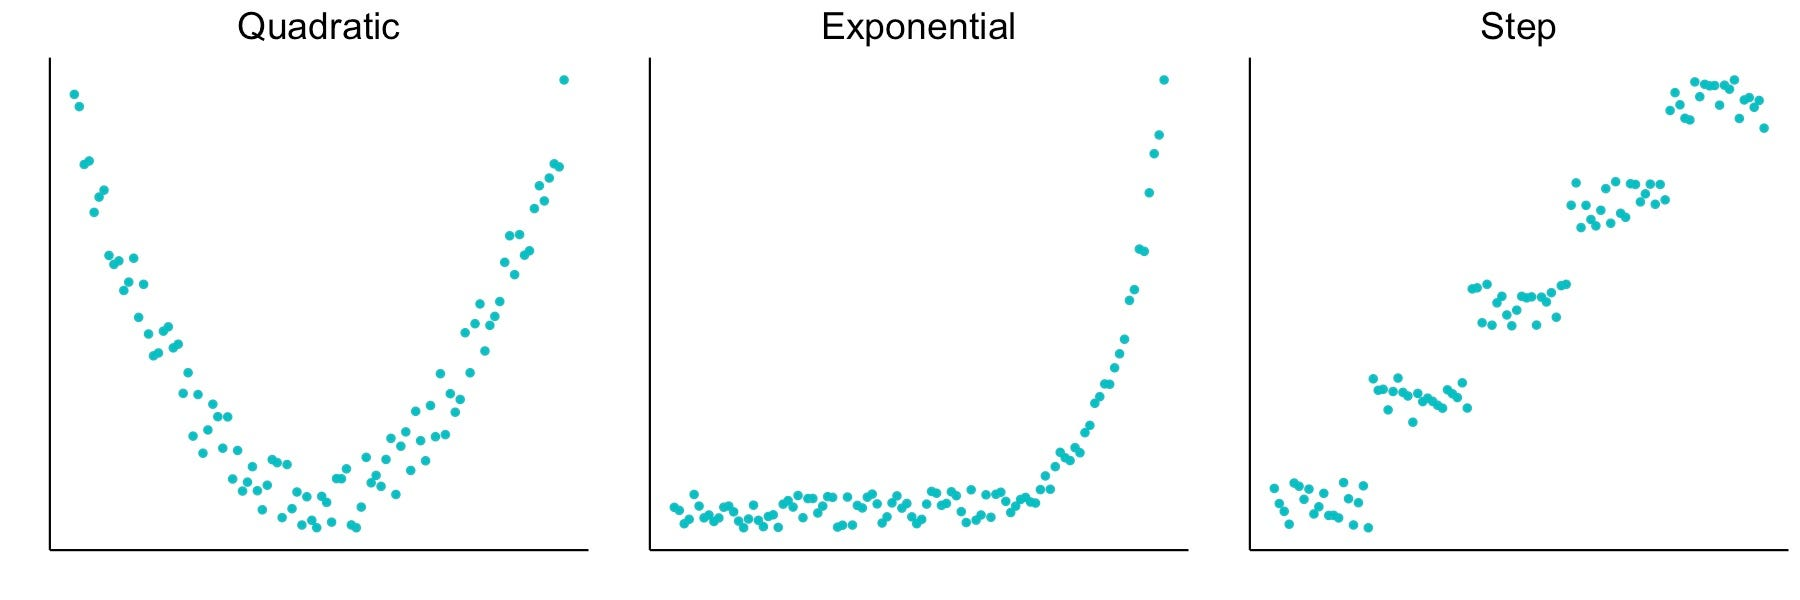
*Ilustración de diferentes tipos de relaciones no-lineales en los datos. Extraído de TowardsDataScience https://towardsdatascience.com/finding-and-visualising-non-linear-relationships-4ecd63a43e7e.*


### **<font color="ForestGreen"> Función potencial </font>**

La función potencial tiene la siguiente forma general:

\begin{align}
y= ax^b
\end{align} 

Lo que podemos traducir a nuestro modelo de regresión como

\begin{align}
\hat{Y}= y= \beta_0x^{\beta_1 }
\end{align}   

Ahora podemos disfrazar a nuestro función nivel: 

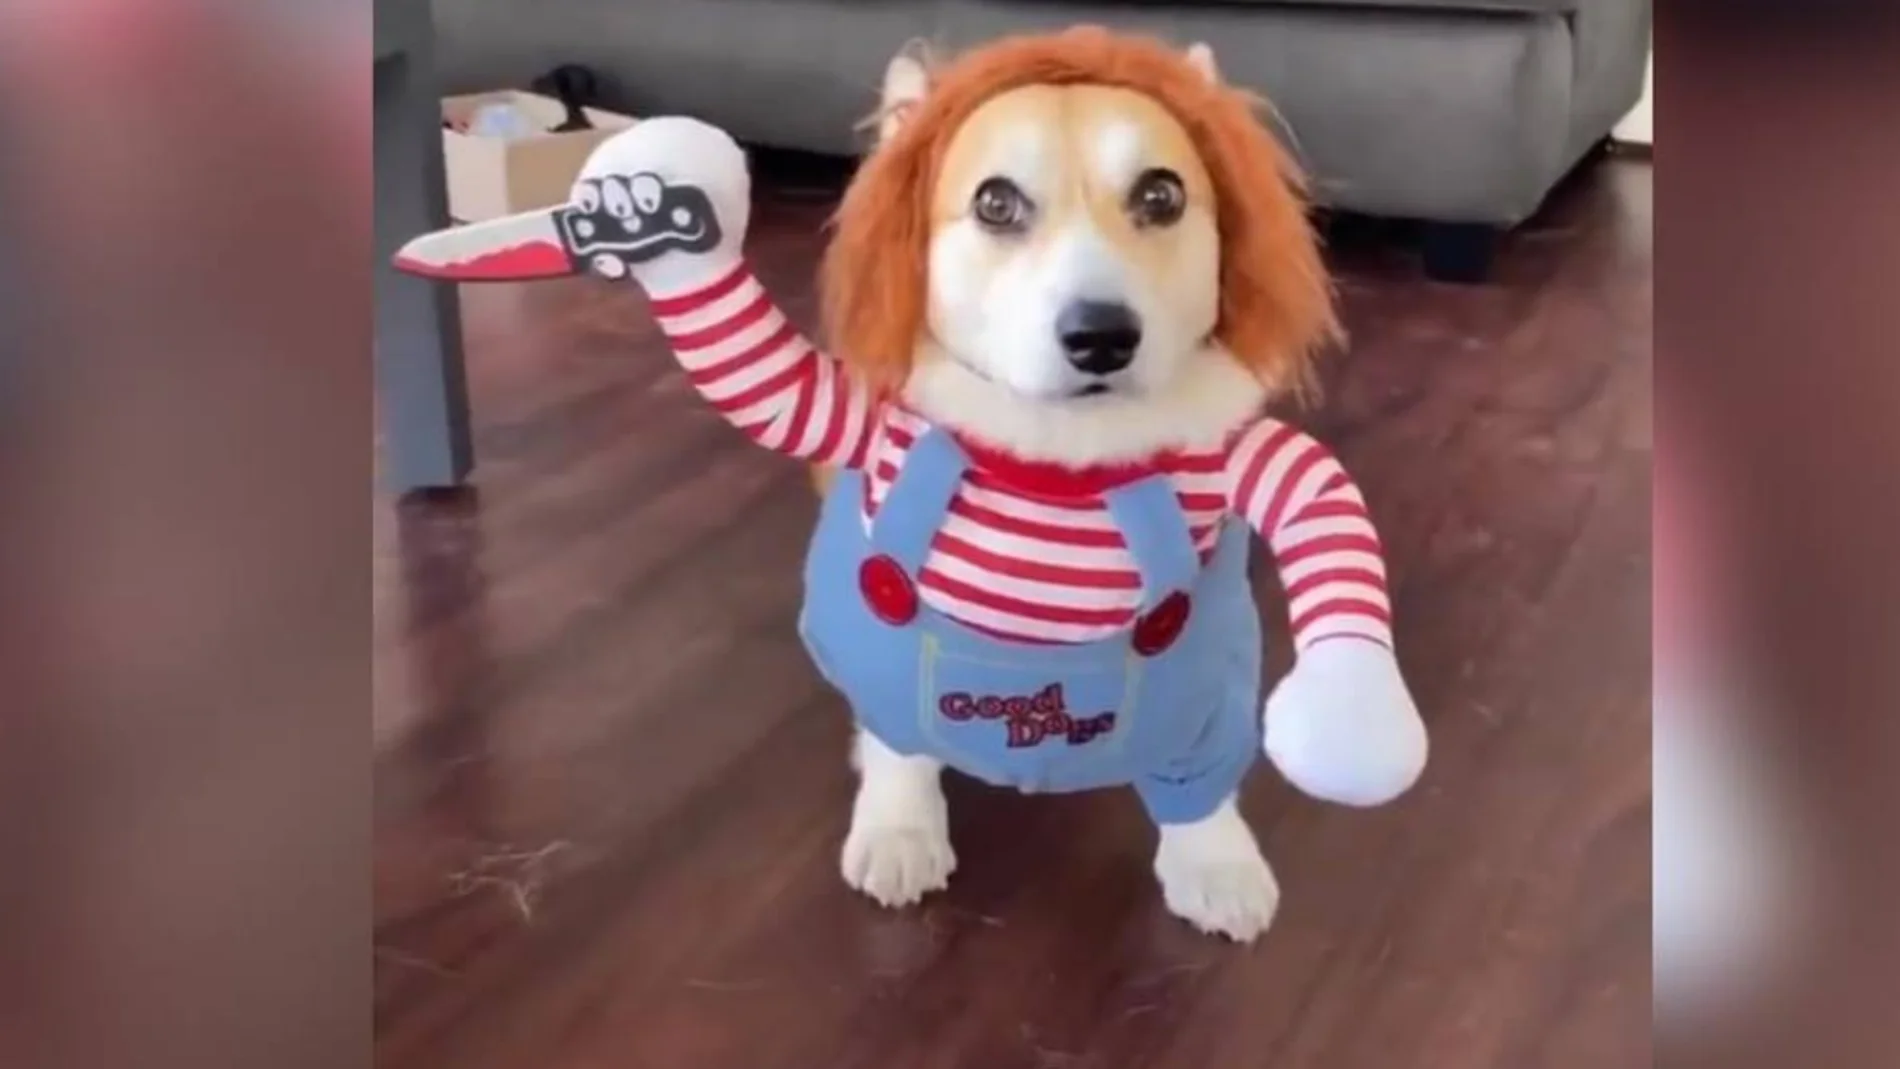

Aplicando logaritmo natural a ambos lados de la ecuación se obtiene:

\begin{align}
ln \bigg(\hat{Y}\bigg)= ln\bigg( \beta_0x^{\beta_1} \bigg)
\end{align} 

y separamos los logaritmos del lado derecho:

\begin{align}
ln \bigg(\hat{Y}\bigg)= ln(\beta_0) + ln(x^{\beta_1})
\end{align}

Una propiedad de los logaritmos es que si un argumento está elevado a un exponente, podemos bajar ese exponente a multiplicar a todo el logaritmo, algo así como:

\begin{align}
ln \bigg(\hat{Y}\bigg)= ln(\beta_0) + \beta_1\, \, ln(x)
\end{align}

Y listo, ahora tenemos una función de la forma:

\begin{align}
\hat{Y}'= \beta_0' +\beta_1' x'
\end{align} 

In [3]:
# Generar datos de ejemplo sinteticos
np.random.seed(0)
X = 5 * np.random.rand(100)  # Variable independiente
ruido = np.random.uniform(-.22, .22, size=len(X))
y = (2+ruido)* (X**(3+ruido))

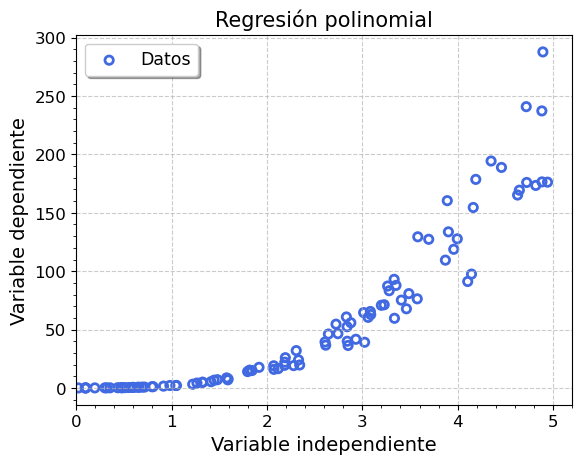

In [4]:
#graficamos los datos para ver con que tipo de relaciones estamos tratando
plt.scatter(X,y,color='royalblue', linewidth=2, facecolor='none', label='Datos')
grafico_linea_ts(0,5.2,'Variable independiente',
                 'Variable dependiente','Regresión polinomial',legend=True)

Una vez que hemos visto como se distribuyen los datos, podemos empezar con el acto de disfrazar a nuestros datos para hacer una regresión lineal. Según las ecuaciones anteriores, es necesario pasar ambas variables `X` y `y` a logaritmos. 

In [5]:
# conversion a logaritmos
logx=np.log(X)
# conversion a logaritmos
logy=np.log(y)

Vamos a graficar lo que obtenemos en el plano logarítmico. ¿Se ve más lineal?

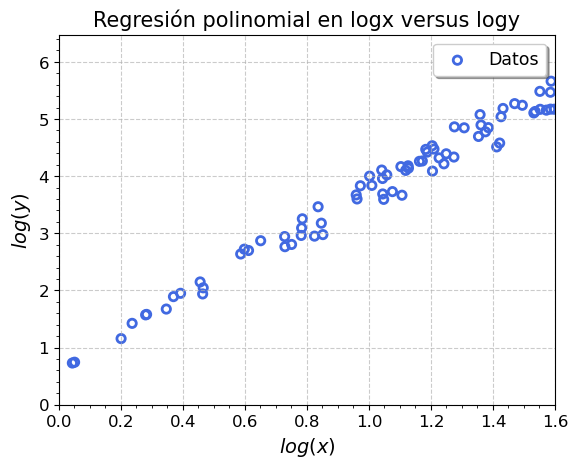

In [6]:
plt.scatter(logx,logy,color='royalblue', linewidth=2, facecolor='none', label='Datos')
grafico_linea_ts(0,1.6,'$log(x)$','$log(y)$','Regresión polinomial en logx versus logy',ymin=0,legend=True)

Una vez hecha la transformación del plano normal al plano logarítmico podemos empezar a hacer la regresión.

In [7]:
from scipy import stats

Una nueva función para calcular la regresión lineal: 

La función `scipy.stats.linregress` se utiliza para realizar una regresión lineal simple entre dos conjuntos de datos. Esta función es parte del submódulo stats de la biblioteca SciPy en Python. La manera de usar `scipy.stats.linregress` es con 2 argumentos, una variable independiente (arreglo) y una dependiente (y) `scipy.stats.linregress(x, y)`. 

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html



La función devuelve un objeto `LinregressResult` que contiene varios valores relevantes relacionados con la regresión lineal. El retorno de esta función son 5 parámetros::

1. slope: La pendiente de la línea de regresión.
2. intercept: El término de intercepción de la línea de regresión.
3. rvalue: El coeficiente de correlación ($r$) entre x e y.
4. pvalue: El valor p asociado al coeficiente de correlación.
5. stderr: El error estándar de la pendiente estimada de la línea de regresión.

In [8]:
resultado = stats.linregress(logx, logy)

Extraemos los resultados a través de los índices correspondientes y hacemos las predicciones para una línea recta en el espacio $log (x)$ versus $log(y)$

In [9]:
b1=resultado[0]
b0=resultado[1]
# evaluamos la variable logx con estos coeficientes para obtener una prediccion y-gorrito
predicciones=b0+b1*logx

También podemos extraer el coeficiente de correlación que según el texto arriba es el tercer parámetro de salida de la función, o el correspondiente al índice 2.

In [10]:
r=resultado[2]

In [11]:
print("el coeficiente de correlación es",np.around(r,3))

el coeficiente de correlación es 0.999


¿Cuál es este coef? ¿Pearson?

Podemos graficar todo ya completo en el plano logarítmico y a ojo de buen cubero, ver la bondad de nuestro ajuste.

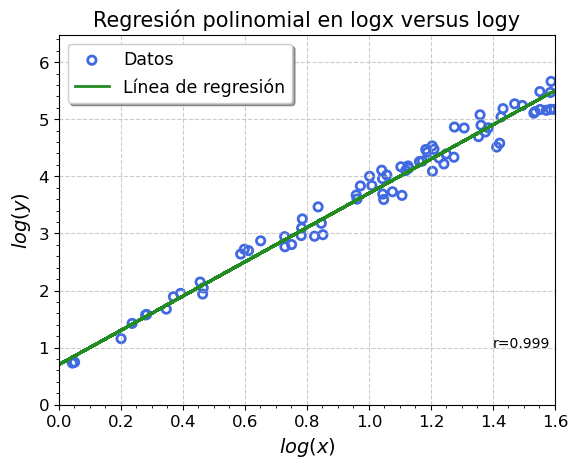

In [12]:
plt.scatter(logx,logy,color='royalblue', linewidth=2, facecolor='none', label='Datos')
plt.plot(logx,predicciones, color='forestgreen',linewidth=2, label='Línea de regresión')
plt.text(1.4,1,"r="+str(np.around(r,3)))
grafico_linea_ts(0,1.6,'$log(x)$','$log(y)$','Regresión polinomial en logx versus logy',ymin=0,legend=True)

Recordando que nuestra ecuación original se podía escribir como:

\begin{align}
\hat{Y}= y= \beta_0x^{\beta_1 }
\end{align}   

y la regla de correspondencia entre los coeficientes en el espacio logarítmico (con el símbolo ') y los coeficientes normales, i.e.:

 $\beta_0' = ln(\beta_0)$
 
 $\beta_1' =  \beta_1'$
 
 $x'= ln(x)$
 
 De la primer igualdad resulta que $\beta_0 = exp(\beta_0')$ y con eso podemos calcular nuestra $\hat{Y}$ original.


In [13]:
# conversion del coeficiente b0
b0real=np.exp(b0)
# hacemos un nuevo arreglo para evaluar el ajuste 
xreal=np.linspace(0,5,100)
# calculando y gorrito original
predicciones_completas=b0real*xreal**b1

Ahora podemos graficar todo en el plano original, con las variables originales.

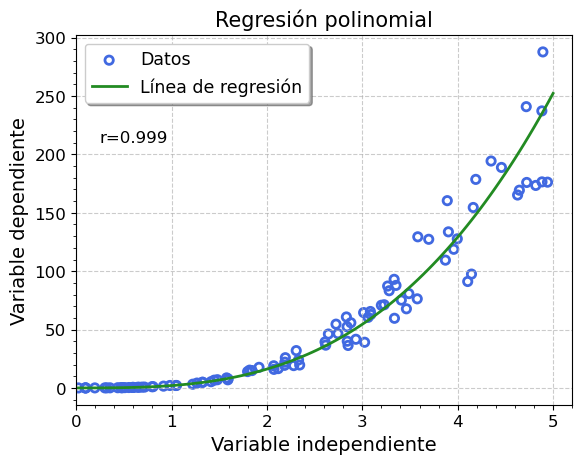

In [14]:
plt.scatter(X,y,color='royalblue', linewidth=2, facecolor='none', label='Datos')
plt.plot(xreal,predicciones_completas, color='forestgreen',linewidth=2, label='Línea de regresión')
plt.text(0.25,210,"r="+str(np.around(r,3)),fontsize=12)
grafico_linea_ts(0,5.2,'Variable independiente',
                 'Variable dependiente','Regresión polinomial',legend=True)

---
<a name='ej-2'></a>
### **<font color="DodgerBlue">Ejercicio 1 - ¿La propina crece linealmente? </font>**

<font color="DarkBlue"> Para este ejercicio trabajará con un conjunto de datos reales disponible en la librería `seaborn`. Si no la tiene instalada, puede instalarla con pip. 

<font color="DarkBlue"> Después, cargue el dataset tips, </font>
```python 
import seaborn as sns
df = sns.load_dataset("tips").dropna()
```

<font color="DarkBlue">    el cual contiene información sobre cuentas y propinas en un restaurante. En particular, utilice las variables total_bill y tip.</font>

<br>

<font color="DarkBlue"> 1. Realice el análisis de regresión entre las variables total_bill y tip utilizando dos modelos: una regresión lineal y una regresión polinomial. Para ello, use únicamente las herramientas y procedimientos trabajados en clase.</font>

<font color="DarkBlue"> 2. Compare ambos ajustes mediante alguna métrica vista en el curso, como el coeficiente de correlación o el coeficiente de determinación. Con base en ello, determine cuál de los dos modelos describe mejor la relación entre la cuenta total y la propina.</font>

<font color="DarkBlue"> 3. Grafique los datos originales junto con las dos curvas ajustadas. En la misma figura, escriba la ecuación del modelo que considere más adecuado de acuerdo con su análisis. Finalmente, explique brevemente sus resultados: indique cómo cambia la propina conforme aumenta el total de la cuenta y discuta si la regresión polinomial representa una mejora clara respecto a la lineal.</font>

<font color="DarkBlue"> Nota: Para este ejercicio se espera que la solución se construya con las herramientas vistas en clase. Si decide utilizar funciones, estructuras o métodos no revisados explícitamente, deberá justificar su uso de manera breve y clara en su entrega.</font>

### **<font color="ForestGreen"> Función exponencial </font>**

La función exponencial tiene la siguiente forma general:

\begin{align}
y= ae^{bx}
\end{align} 

Lo que podemos traducir a nuestro modelo de regresión como

\begin{align}
\hat{Y}= y= \beta_0e^{\beta_1 x }
\end{align}   


Podemos disfrazar esta función también: 

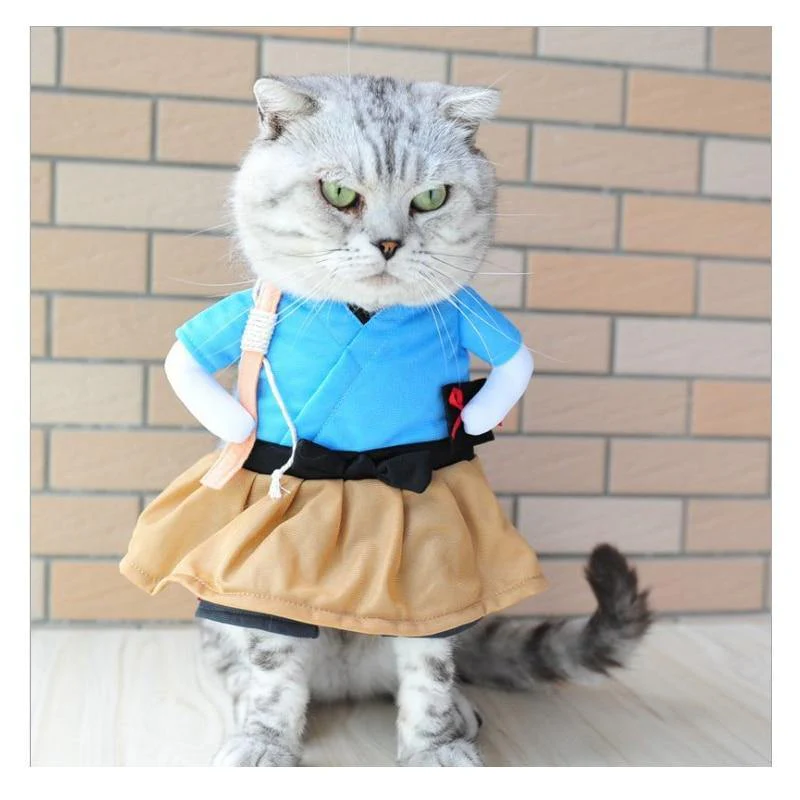

Aplicando logaritmo natural a ambos lados de la ecuación se obtiene:

\begin{align}
ln \bigg(\hat{Y}\bigg)= ln\bigg( \beta_0e^{x\beta_1} \bigg)
\end{align} 

y separamos los logaritmos del lado derecho:

\begin{align}
ln \bigg(\hat{Y}\bigg)= ln(\beta_0) + ln(e^{x\beta_1})
\end{align}

Por reglas de los logaritmos, el logaritmo natural de $e$ desaparece:

\begin{align}
ln \bigg(\hat{Y}\bigg)= ln(\beta_0) + \beta_1x
\end{align}

Y listo, ahora tenemos una función de la forma:

\begin{align}
\hat{Y}'= \beta_0' +\beta_1' x'
\end{align} 

Ahora podemos repetir nuestro anális para otros datos:

In [15]:
# Generar datos de ejemplo sinteticos
X = 5 * np.random.rand(100)  # Variable independiente
ruido = np.random.uniform(-.11, .11, size=len(X))
y = (2+ruido)*np.exp(X*(1.2+ruido))

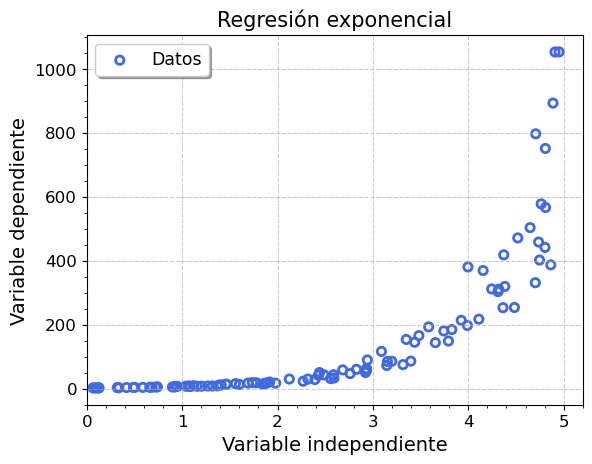

In [16]:
# grafico de exploracion de los datos
plt.scatter(X,y,color='royalblue', linewidth=2, facecolor='none', label='Datos')
grafico_linea_ts(0,5.2,'Variable independiente',
                 'Variable dependiente','Regresión exponencial',legend=True)

De la misma manera que para la regresión polinomial, necesitamos hacer conversiones entre variables a logaritmos ¿ahora quién necesita el disfraz?

In [17]:
# conversion a logaritmos
logy=np.log(y)

In [18]:
# regresion con linregress
resultado = stats.linregress(X, logy)

In [19]:
# leemos los resultados de linregress
b1=resultado[0]
b0=resultado[1]
r=resultado[2]
print(b1,b0,r)

1.1810044373212265 0.7119112481613343 0.9935929407352093


Recordando que nuestra ecuación original se podía escribir como:

\begin{align}
\hat{Y}= y= \beta_0e^{\beta_1 x }
\end{align}   

y la regla de correspondencia entre los coeficientes en el espacio logarítmico (con el símbolo ') y los coeficientes normales, i.e.:

 $\beta_0' = ln(\beta_0)$
 
 $\beta_1' =  \beta_1'$
 
 $x'= x$
 
 De la primer igualdad resulta que $\beta_0 = exp(\beta_0')$ y con eso podemos calcular nuestra $\hat{Y}$ original.

In [20]:
# conversion entre beta prima y beta
b0real=np.exp(b0)
# hacemos un nuevo vector de x para evaluar nuestra predicciones aquí
xreal=np.linspace(0,5,100)
predicciones_completas=b0real*np.exp(xreal*b1)

Viendo los valores de $\beta_0$ y $\beta_1$, ¿cómo se puede escribir la función de regresión final?

Podemos ahora terminar el ejercicio con una gráfica de la línea de regresión y de los datos.

In [21]:
# auxiliar para graficar bonito. Truco de profe indescifrable para les estudiantes. Para averiguar los secretos, conteste ¿cuántas terrologosfest fueron organizados por los profesores de esta materia?
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

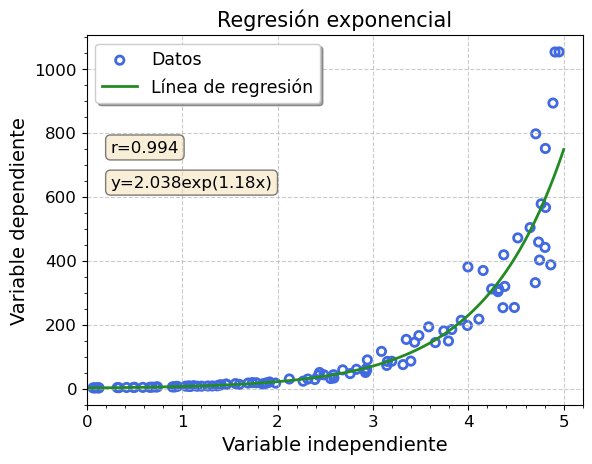

In [22]:
plt.scatter(X,y,color='royalblue', linewidth=2, facecolor='none', label='Datos')
plt.plot(xreal,predicciones_completas, color='forestgreen',linewidth=2, label='Línea de regresión')
# agregamos texto directamente a la grafica para mostrar la ecuacion de regresion y el coeficiente de correlacion. ... 
plt.text(.25,740,"r="+str(np.around(r,3)),fontsize=12,bbox=props)
plt.text(.25,630,"y="+str(np.around(b0real,3))+r"exp("+str(np.around(b1,2))+"x)",fontsize=12,bbox=props)
grafico_linea_ts(0,5.2,'Variable independiente',
                 'Variable dependiente','Regresión exponencial',legend=True)

Ahora vamos a hacer un ejercicio utilizando unos datos obtenidos de https://gist.github.com/RobotOptimist/cc82e87e7d2104e58711b7c846a9e220 para entender cómo varía el salario en una compañía en EUA como función del nivel en la compañía. 

In [23]:
# cargamos los datos
df=df=pd.read_csv('position_salaries.csv',header=0)
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


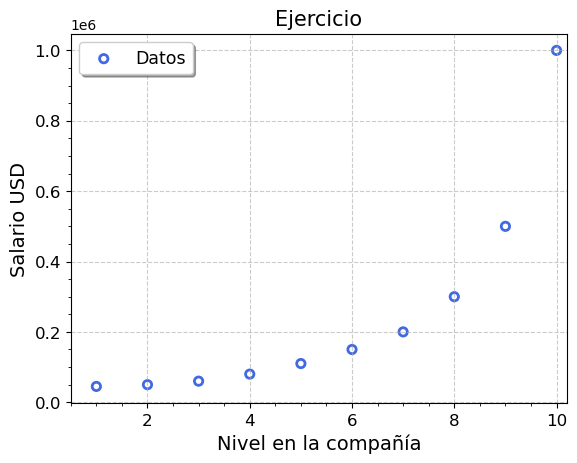

In [24]:
plt.scatter(df.Level,df.Salary,color='royalblue', linewidth=2, facecolor='none', label='Datos')
grafico_linea_ts(0.5,10.2,'Nivel en la compañía',
                 'Salario USD','Ejercicio',legend=True)

---
<a name='ej-1'></a>
### **<font color="DodgerBlue">Ejercicio 2 - El CEO no tiene quién le escriba </font>**

<font color="DarkBlue"> 1. Realice el análisis de regresión no-lineal para las variables de "Nivel" y "Salario" utilizando la regresión exponencial y la polinomial. 
    
<font color="DarkBlue"> 2. Determine, a travé de los coeficientes de correlación resultantes, ¿cuál es el mejor ajuste, el exponencial o el polinomial?
        
<font color="DarkBlue"> 3. Grafique los datos junto con sus 2 líneas ajustadas y escriba en el gráfico la ecuación que mejor describe a los datos, i.e., su resultado del punto 2. Explique sus resultados indicando cómo varía el salario dependiendo el nivel y qué tan diferente es el salario en una posición de entrada comparado con un CEO.
       
    
---

### **<font color="ForestGreen"> Función hiperbólica </font>**

La función hiperbólica tiene la siguiente forma:

\begin{align}
y=a+\frac{b}{x}
\end{align}

que en nuestra notación sería: 

\begin{align}
\hat{y}=\beta_0+\frac{\beta_1}{x}
\end{align}

donde $x'=\frac{1}{x}$.



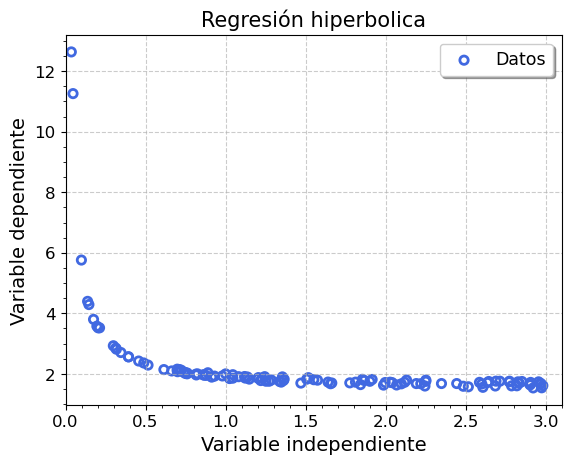

In [25]:
# Generar datos de ejemplo sinteticos
X = 3 * np.random.rand(120)  # Variable independiente
ruido = np.random.uniform(-.125, .125, size=len(X))
y = (1.5+ruido) + 0.5/(X*(1.2+ruido))

plt.scatter(X,y,color='royalblue', linewidth=2, facecolor='none', label='Datos')
grafico_linea_ts(0,3.1,'Variable independiente',
                 'Variable dependiente','Regresión hiperbolica',legend=True)

In [26]:
# conversion entre x y xprima
xprima=1/X

In [27]:
# regresion con linregress
resultado = stats.linregress(xprima, y)

In [28]:
# leemos los resultados de linregress
b1=resultado[0]
b0=resultado[1]
r=resultado[2]
print(b1,b0,r)

0.420461046204632 1.498896970690133 0.9973623930853347


Recordando que nuestra ecuación original se podía escribir como:

\begin{align}
\hat{Y}= y= \beta_0+\frac{\beta_1}{x}
\end{align}   

y la regla de correspondencia entre los coeficientes, podemos calcular nuestra $\hat{Y}$ original. 

<div class="alert alert-block alert-info">
<b>Nota:</b> Debido a que los coeficientes de regresión no fueron disfrazados, no es necesario reconvertirlos. Sólo necesitamos evaluar bien la función como dicta la ecuación anterior con un vector de la variable $x$ bien definido.
</div>

In [29]:
# hacemos un nuevo vector de x para evaluar nuestra predicciones aquí
xvec=np.linspace(0,4,100)
predicciones_completas=b0+ b1/xvec

/tmp/ipykernel_50363/2845356857.py:3: RuntimeWarning: divide by zero encountered in divide
  predicciones_completas=b0+ b1/xvec


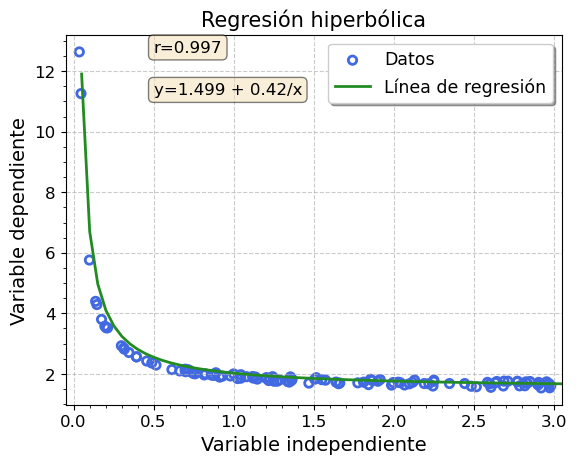

In [30]:
# evaluamos todo en la grafica
plt.scatter(X,y,color='royalblue', linewidth=2, facecolor='none', label='Datos')
plt.plot(xreal,predicciones_completas, color='forestgreen',linewidth=2, label='Línea de regresión')
# agregamos texto directamente a la grafica para mostrar la ecuacion de regresion y el coeficiente de correlacion. ... 
plt.text(0.5,np.max(y),"r="+str(np.around(r,3)),fontsize=12,bbox=props)
plt.text(0.5,np.max(y)-np.max(y)/9,"y="+str(np.around(b0,3))+" + "+str(np.around(b1,3))+"/x",fontsize=12,bbox=props)
grafico_linea_ts(-0.05,3.05,'Variable independiente',
                 'Variable dependiente','Regresión hiperbólica',legend=True)

### **<font color="ForestGreen"> Regresión logística </font>**

La regresión logística es otro tipo de regresión no lineal. De manera más común, es un tipo de análisis estadístico utilizado para modelar una variable de respuesta categórica (binaria o multinomial) en función de una o más variables predictoras. La regresión logística la veremos en 2 sabores, uno como 1 método más de regresión no-lineal, y otro como un método de clasificación, análogo a los vistos en la clase de ML.

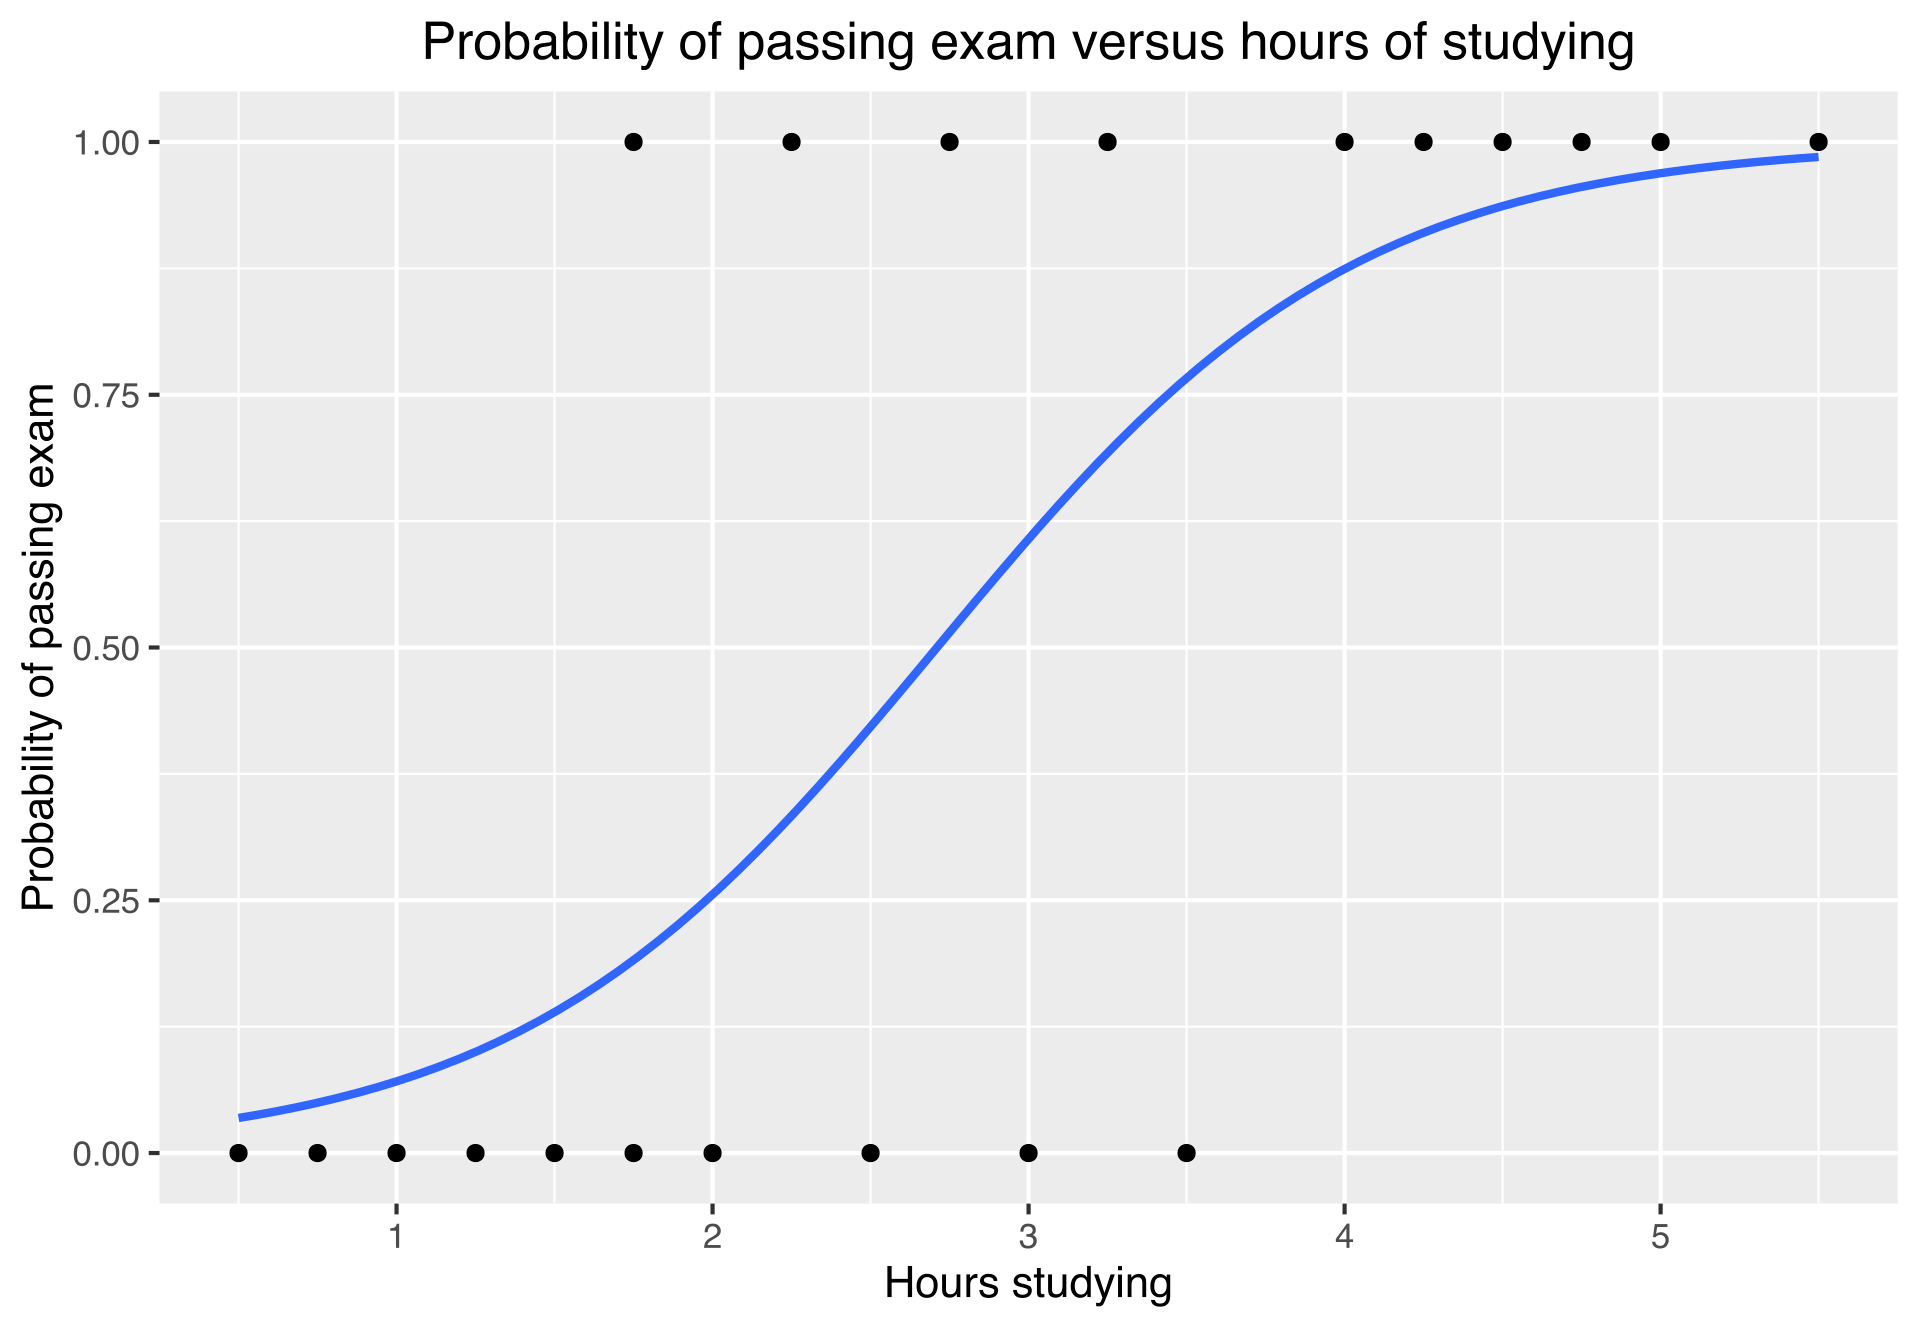
*La probabilidad de pasar un examen puede ser función de las horas utilizadas para estudiar, pero no es necesariamente una función lineal, sino una función de probabilidad que puede ser descrita por una función logística.*

#### **<font color="ForestGreen"> Regresión logística como un método más de regresión </font>**

En una versión, funciona tal como las otras regre diferencia de la regresión lineal, que predice valores continuos, la regresión logística predice la probabilidad de ocurrencia de un evento al ajustarse a una curva logística.

La función que queremos ajustar en este tipo de regresión es: 

\begin{align}
\hat{y}=\frac{1}{1+e^{\beta_0+\beta_1x}}
\end{align}

Sólo que en este caso no haremos el proceso de disfrazar a la función ya que no se puede hacer analíticamente, necesitamos más poder. 


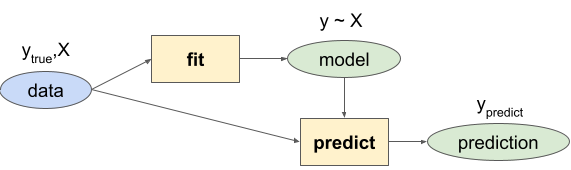

---
<a name='ej-1'></a>
### **<font color="OrangeRed">Ejemplo: Exoplanetas </font>**

<font color="DarkRed"> El descubrimiento de exoplanetas ha experimentado un notable cambio a lo largo del tiempo, impulsado por avances tecnológicos, metodológicos y teóricos. El lanzamiento del telescopio espacial Kepler en 2009 revolucionó el campo al monitorear más de 150,000 estrellas de manera continua, utilizando la técnica de tránsito. Kepler descubrió miles de exoplanetas, muchos de los cuales eran de tamaño terrestre o supertierras en las zonas habitables de sus estrellas.
    
<font color="DarkRed"> Utilizando el catálogo de exoplanetas de la NASA https://science.nasa.gov/exoplanets/exoplanet-catalog/ podemos analizar diferentes variables de cómo y cuáles exoplanetas han sido descubiertos.    
    
<font color="DarkRed">   1. Haga un análisis de regresión logística para las variables de # de exoplanetas descubiertos versus el año en el que fueron descubiertos. 

---

In [37]:
# cargamos datos con pandas
df=pd.read_csv('exo_Data.csv',header=0)
df

,name,planet_status,mass,mass_error_min,mass_error_max,mass_sini,mass_sini_error_min,mass_sini_error_max,radius,radius_error_min,...,star_sp_type,star_age,star_age_error_min,star_age_error_max,star_teff,star_teff_error_min,star_teff_error_max,star_detected_disc,star_magnetic_field,star_alternate_names
0,11 Com b,Confirmed,16.1284,1.53491,1.53491,16.1284,1.53491,1.53491,NaN,NaN,...,G8 III,NaN,NaN,NaN,4742.0,100.0,100.0,NaN,NaN,NaN
1,11 Oph b,Confirmed,21.0000,3.00000,3.00000,NaN,NaN,NaN,NaN,NaN,...,M9,0.011,0.002,0.002,2375.0,175.0,175.0,NaN,NaN,"Oph 1622-2405, Oph 11A"
2,11 UMi b,Confirmed,11.0873,1.10000,1.10000,11.0873,1.10000,1.10000,NaN,NaN,...,K4III,1.560,0.540,0.540,4340.0,70.0,70.0,NaN,NaN,NaN
3,14 And b,Confirmed,4.6840,0.23000,0.23000,4.6840,0.23000,0.23000,NaN,NaN,...,K0III,NaN,NaN,NaN,4813.0,20.0,20.0,NaN,NaN,NaN
4,14 Her b,Confirmed,NaN,NaN,NaN,NaN,4.95000,4.95000,NaN,NaN,...,K0 V,5.100,NaN,NaN,5311.0,87.0,87.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5666,ZTFJ0220+21 b,Confirmed,14.0000,6.00000,6.00000,NaN,NaN,NaN,0.54,0.07,...,WD,NaN,NaN,NaN,14200.0,1000.0,1000.0,NaN,NaN,NaN
5667,ZTFJ0407-00 b,Confirmed,19.0000,3.00000,3.00000,NaN,NaN,NaN,0.44,0.02,...,WD,NaN,NaN,NaN,17400.0,1200.0,1200.0,NaN,NaN,NaN
5668,ZTF-J1622+47 b,Confirmed,61.0000,19.00000,19.00000,NaN,NaN,NaN,0.98,0.02,...,NaN,NaN,NaN,NaN,29000.0,NaN,NaN,NaN,NaN,NaN
5669,ZTFJ1637+49 b,Confirmed,23.0000,8.00000,8.00000,NaN,NaN,NaN,0.68,0.07,...,WD,NaN,NaN,NaN,11200.0,300.0,300.0,NaN,NaN,NaN


In [34]:
df.columns

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

Text(0.5, 1.0, 'Scatter plot con seaborn')

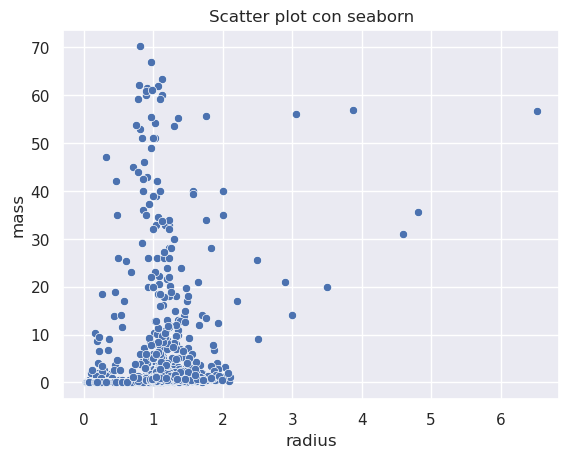

In [38]:
sns.set_theme()
sns.scatterplot(data=df,x='radius',y='mass')
plt.title('Scatter plot con seaborn')

Las columnas que sí nos interesa analizar son las que corresponden al nombre (`df.name`) y al año en el que fueron descubiertos los exoplanetas (`df.discovered`). 

Para esto podemos hacer un `df.groupby` y hacer el conteo `.count()` lo cual nos dirá cuántos exoplanetas fueron descubiertos cada año.

In [39]:
cuentas=df.groupby(df.discovered).count()['name']
print(cuentas)

discovered
1992.0       3
1995.0       3
1996.0       7
1997.0       1
1998.0       6
1999.0      16
2000.0      24
2001.0      15
2002.0      33
2003.0      31
2004.0      34
2005.0      37
2006.0      39
2007.0      66
2008.0      67
2009.0      90
2010.0     136
2011.0     208
2012.0     147
2013.0     185
2014.0     868
2015.0     170
2016.0    1536
2017.0     216
2018.0     359
2019.0     238
2020.0     245
2021.0     224
2022.0     343
2023.0     236
2024.0      76
Name: name, dtype: int64


Si, además, queremos calcular la suma acumulada de exoplanetas descubiertos, podemos utilizar la función `cumsum()` que nos hace este cálculo.

In [40]:
acumulado=cuentas.cumsum()
acumulado

discovered
1992.0       3
1995.0       6
1996.0      13
1997.0      14
1998.0      20
1999.0      36
2000.0      60
2001.0      75
2002.0     108
2003.0     139
2004.0     173
2005.0     210
2006.0     249
2007.0     315
2008.0     382
2009.0     472
2010.0     608
2011.0     816
2012.0     963
2013.0    1148
2014.0    2016
2015.0    2186
2016.0    3722
2017.0    3938
2018.0    4297
2019.0    4535
2020.0    4780
2021.0    5004
2022.0    5347
2023.0    5583
2024.0    5659
Name: name, dtype: int64

In [41]:
acumulado.name='conteo'

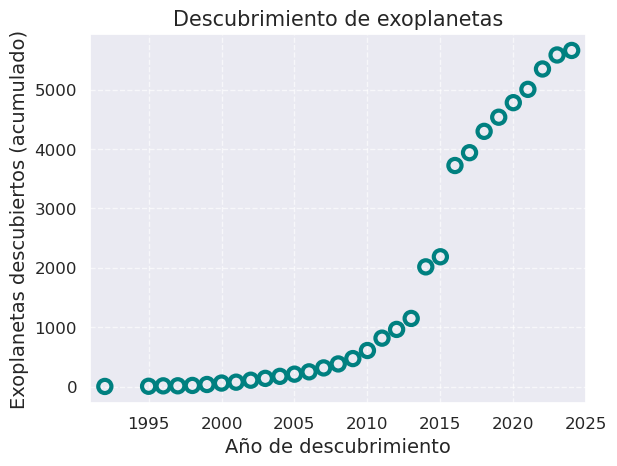

In [42]:
plt.scatter(acumulado.index,acumulado,color='teal', linewidth=3, s=90, facecolor='none', label='Datos')
grafico_linea_ts(1991,2025,'Año de descubrimiento','Exoplanetas descubiertos (acumulado)','Descubrimiento de exoplanetas',ymin=None,ymax=None,legend=False)

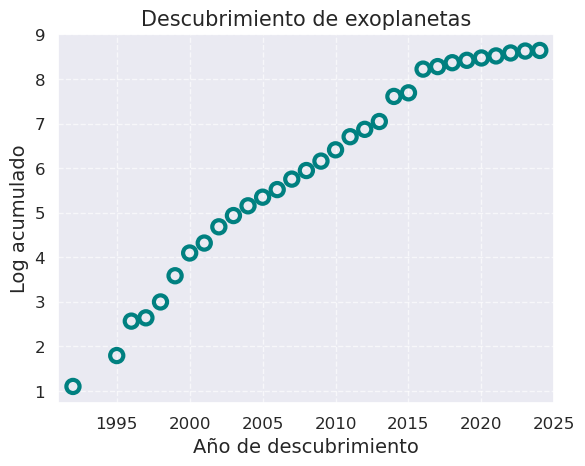

In [43]:
plt.scatter(acumulado.index,np.log(acumulado),color='teal', linewidth=3, s=90, facecolor='none', label='Datos')
grafico_linea_ts(1991,2025,'Año de descubrimiento','Log acumulado','Descubrimiento de exoplanetas',ymin=None,ymax=None,legend=False)

Antes de proceder a hacer la regresión logística es importante notar que esta función, la logística:

\begin{align}
\hat{y}=\frac{1}{1+e^{\beta_0+\beta_1x}}
\end{align}

está delimitada entre los valores de 0 y 1, por lo que es necesario acomodar nuestros datos para satisfacer esta condición.

Para esto, haremos un nuevo dataframe, uno donde los valores del acumulado de descubrimientos estén restringidos al intervalo $[0,1]$.

In [44]:
df=acumulado.reset_index()
df

,discovered,conteo
0,1992.0,3
1,1995.0,6
2,1996.0,13
3,1997.0,14
4,1998.0,20
5,1999.0,36
6,2000.0,60
7,2001.0,75
8,2002.0,108
9,2003.0,139


In [45]:
# normalizamos los datos por el valor maximo
maxi=df['conteo'].max()
df['conteo']=df['conteo']/maxi

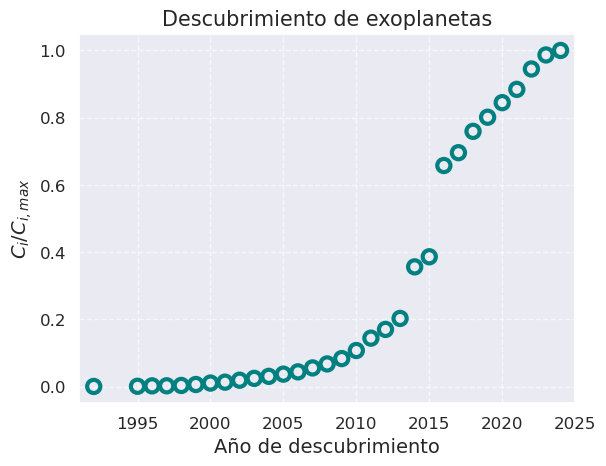

In [46]:
plt.scatter(df.discovered,df.conteo,color='teal', linewidth=3, s=90, facecolor='none', label='Datos')
grafico_linea_ts(1991,2025,'Año de descubrimiento','$C_i/C_{i,max}$','Descubrimiento de exoplanetas',ymin=None,ymax=None,legend=False)

Ahora, tendremos que utilizar una función diferente para hacer nuestra regresión con `statsmodels`.

`statsmodels.formula.api` es un módulo de la biblioteca `statsmodels` en Python que proporciona una interfaz para especificar y ajustar modelos estadísticos utilizando fórmulas al estilo de R. Este enfoque facilita la construcción de modelos de regresión al permitir especificar las relaciones entre las variables de manera intuitiva y declarativa. 

La función `logit` en el módulo `statsmodels.formula.api` se utiliza para ajustar modelos de regresión logística. Para usarla, se necesita un DataFrame con tus datos. Usa la función logit para especificar el modelo con una fórmula. La fórmula se pasa como una cadena de texto y sigue la notación estándar (por ejemplo, y ~ x1 + x2).



In [47]:
import statsmodels.formula.api as smf

En nuestro caso, la variable $y$ es el conteo y la $x$ es el año en el que fueron descubiertos. Entonces utilizando el dataframe podemos escribir:

In [48]:
model = smf.logit('conteo ~ discovered', data=df)
fit = model.fit()

Optimization terminated successfully.
         Current function value: 0.183203
         Iterations 9


Recordando cómo funcionaba statsmodels del notebook anterior, un resultado de un modelo con este paquete tiene los siguientes atributos principales:

lgunos de los atributos más importantes de este objeto son:

- `params`: Este atributo devuelve los coeficientes estimados para cada variable independiente en el modelo de regresión. Por ejemplo, si tienes un modelo con una variable independiente, params devolverá el coeficiente estimado para esa variable.

- `rsquared`: Este atributo devuelve el coeficiente de determinación ($R^2$) del modelo de regresión. Proporciona una medida de qué tan bien se ajustan los valores predichos por el modelo a los valores reales de la variable dependiente.

- `summary()` en Statsmodels se utiliza para obtener un resumen detallado del modelo de regresión lineal ajustado. Proporciona una descripción completa de las estadísticas relevantes del modelo, incluyendo los coeficientes estimados, los errores estándar, los valores p, las estadísticas de ajuste y más. 

In [49]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 conteo   No. Observations:                   31
Model:                          Logit   Df Residuals:                       29
Method:                           MLE   Df Model:                            1
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.6796
Time:                        18:35:27   Log-Likelihood:                -5.6793
converged:                       True   LL-Null:                       -17.727
Covariance Type:            nonrobust   LLR p-value:                 9.167e-07
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -760.6569    288.751     -2.634      0.008   -1326.599    -194.715
discovered     0.3775      0.143      2.634      0.008       0.097       0.658
==============================================================================
"""

In [50]:
b0=fit._results.params[0]
b1=fit._results.params[1]

Habiendo calculado los coeficientes de la ecuación logística, es importante recordar que la forma de esta función es:

\begin{align}
\hat{y}=\frac{1}{1+e^{\beta_0+\beta_1x}}
\end{align}

y que nuestros datos estaban normalizados por el valor máximo, por lo que podemos hacer una predicción de nuestros datos completa a través de la ecuación:

\begin{align}
\hat{y}=\frac{x_{max}}{1+e^{\beta_0+\beta_1x}}
\end{align}

In [ ]:
yhat=np.max(acumulado.values)/(1+np.exp(-(b0+b1*df.discovered)))

In [ ]:
# grafica con regresion 
plt.plot(acumulado.index,np.squeeze(yhat),c='m',linewidth=2.2,linestyle='--')
plt.scatter(acumulado.index,acumulado,color='teal', linewidth=3, s=90, facecolor='none', label='Datos')
grafico_linea_ts(1991,2025,'Año de descubrimiento','$C_i/C_{i,max}$','Descubrimiento de exoplanetas',ymin=None,ymax=None,legend=False)

---
<a name='ej-1'></a>
### **<font color="DodgerBlue">Ejercicio 3 - El otoño de las poblaciones </font>**

<font color="DarkBlue"> Utilizando los datos de población siguientes:
    
<font color="DarkBlue"> 1. Seleccione los datos correspondientes a uno de los siguientes países: Brasil, Japón o Corea.
   
   <font color="DarkBlue"> 2. Haga un gráfico de dispersión de la población del país que escogió como función del año. 
         
    
<font color="DarkBlue"> 3. Realice un ajuste de regresión logística a los datos contrastando las variables `Year` contra `Value`.
       
    
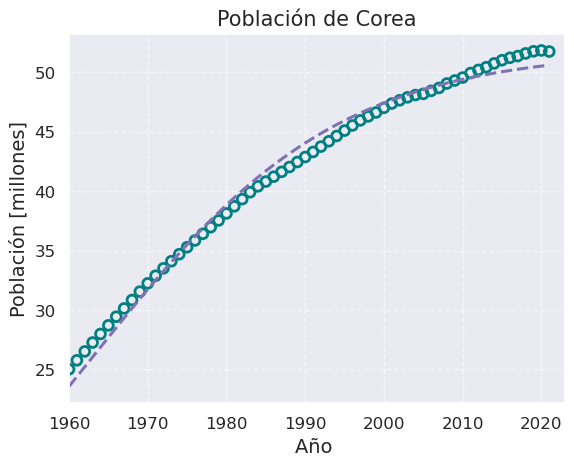
    
---

In [ ]:
df=pd.read_csv('population.csv')
df['Country Name'].unique()

### **<font color="ForestGreen"> Regresión lineal multivariada </font>**

La regresión lineal multivariada es una extensión de la regresión lineal simple que permite modelar la relación entre una variable dependiente continua y múltiples variables independientes (predictoras). Es una técnica ampliamente utilizada en diversos campos para predecir el valor de una variable de interés basándose en la influencia conjunta de varias variables.

Este tipo de regresión es una herramienta estadística poderosa y versátil que permite analizar y predecir la influencia conjunta de múltiples variables independientes sobre una variable dependiente continua.

El modelo de regresión lineal multivariada se representa como:

\begin{align}
\hat{y}=\beta_0+\beta_1 x_1+ \beta_2 x_2+ ... \beta_n x_n + \epsilon
\end{align}

donde:

- $Y$ es la variable dependiente.
- $\beta_0$ es la ordenada al origen (intercepto).
- $\beta_1,\,\beta_2,\,\beta_n$ son los coeficientes de las variables predictoras.
- $x_1,\,x_2,\,x_n$ son las variables independientes.
- $\epsilon$ es el término de error que captura la variabilidad no explicada por las variables predictoras.

Antes de empezar a hacer un análisis, vamos a cargar otro módulo de `scikit-learn` para poder evaluar nuestros modelos y regresiones rápidamente.
El módulo metrics de la biblioteca `scikit-learn` proporciona una amplia gama de herramientas y funciones para evaluar el rendimiento de los modelos de aprendizaje automático. Este módulo es esencial para validar y comparar modelos, asegurando que sean efectivos y generalicen bien a nuevos datos. Recuerden que 2 maneras de medir qué tan bueno es un modelo es con el error cuadrático medio y el R$^2$.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score


### **<font color="ForestGreen"> Ejemplo: el suelo en su laberinto </font>**

Supongamos que somos científicos ambientales interesados en predecir la calidad del suelo en diferentes áreas agrícolas. Sabemos que la calidad del suelo está influenciada por varios factores, incluyendo la cantidad de nutrientes como nitrógeno, fósforo y potasio presentes en el suelo. Nuestro objetivo es desarrollar un modelo de regresión lineal multivariada que nos permita predecir la calidad del suelo basada en las mediciones de estos nutrientes.
Descripción de los Datos

Para este análisis, generamos un conjunto de datos sintéticos que simulan las mediciones de nutrientes y la calidad del suelo:

- Nitrógeno (N): Cantidad de nitrógeno en el suelo (valores entre 0 y 100).
- Fósforo (P): Cantidad de fósforo en el suelo (valores entre 0 y 50).
- Potasio (K): Cantidad de potasio en el suelo (valores entre 0 y 80).
- Calidad del Suelo: Valor numérico que representa la calidad del suelo, calculado como una combinación lineal de los nutrientes con un poco de ruido aleatorio para simular variabilidad en los datos reales.

In [ ]:
# Generar datos aleatorios
np.random.seed(42)
n_samples = 100

nitrogeno = np.random.rand(n_samples) * 100  # valores entre 0 y 100
fosforo = np.random.rand(n_samples) * 50    # valores entre 0 y 50
potasio = np.random.rand(n_samples) * 80    # valores entre 0 y 80

# Calidad del suelo como una función de las variables predictoras con algo de ruido
calidad_suelo = (2.5+np.random.randn(n_samples)/10) * nitrogeno - (4.5+np.random.randn(n_samples)/10) * fosforo + 3 * potasio + np.random.randn(n_samples) * 12

# Crear un DataFrame de pandas con los datos generados
data = {
    'Nitrógeno': nitrogeno,
    'Fósforo': fosforo,
    'Potasio': potasio,
    'Calidad_Suelo': calidad_suelo
}

df = pd.DataFrame(data)


In [ ]:
df

In [ ]:
# scatter plot de seaborn
sns.scatterplot(data=df,x='Nitrógeno',y='Calidad_Suelo')

In [ ]:
sns.scatterplot(data=df,x='Fósforo',y='Calidad_Suelo')

Separamos las variables predictoras (X) de la variable dependiente (y) y dividimos los datos en conjuntos de entrenamiento y prueba. Esto es parte de hacer análisis de datos, pasar de la parte imaginaria (lo que creo que tengo que hacer) al objetivo, requiere una serie de pasos que muchas veces dependen de los paquetes o funciones que usemos. En este caso, tenemos que hacer lo siguiente:

In [ ]:
# Separar las variables predictoras (X) y la variable dependiente (y)
X = df[['Nitrógeno', 'Fósforo', 'Potasio']]
y = df['Calidad_Suelo']

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

In [ ]:
X_test

Utilizamos la clase `LinearRegression` de scikit-learn para crear el modelo de regresión lineal y lo entrenamos con los datos de entrenamiento.

In [ ]:
# Crear y entrenar el modelo
model = LinearRegression()

In [ ]:
# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

In [ ]:
# Hacer predicciones con los datos de prueba
y_pred = model.predict(X_test)

In [ ]:
# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)
print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R^2):", r2)

# Salida de las predicciones
print("Predicciones:", y_pred)

In [ ]:
plt.figure(figsize=(7,11),dpi=120)
for ivar,variable in enumerate(['Fósforo','Nitrógeno','Potasio']):
    plt.subplot(311+ivar)
    plt.scatter(X_test[variable],y_test,label='Datos prueba',marker='s')
    plt.scatter(X_test[variable],y_pred,label='Predicciones',marker='P')
    grafico_linea_ts(0,50,variable,
                 'Calidad del suelo','Regresión multivariada',legend=True)
plt.tight_layout()

---
<a name='ej-4'></a>
### **<font color="DodgerBlue">Ejercicio 4 - Regresión lineal multivariada con pingüinos </font>**

<font color="DarkBlue"> Utilice el dataset `penguins` para modelar la variable `body_mass_g` como función de las variables `bill_length_mm`, `bill_depth_mm` y `flipper_length_mm`.</font>

<font color="DarkBlue"> **1.** Limpie los datos necesarios y ajuste una regresión lineal multivariada usando únicamente las herramientas vistas en clase.</font>

<font color="DarkBlue"> **2.** Divida los datos en conjuntos de entrenamiento y prueba. Reporte al menos la ecuación ajustada del modelo, los coeficientes obtenidos y una métrica estándar de desempeño, como \(R^2\).</font>

<font color="DarkBlue"> **3.** Elabore una gráfica de valores observados contra valores predichos y discuta brevemente qué tan bien las variables morfológicas seleccionadas permiten explicar la masa corporal de los pingüinos.</font>

<font color="DarkBlue"> **Nota:** Se espera que la solución se construya con las herramientas y procedimientos trabajados en clase.</font>

---